# Clasificador LSTM desde cero sobre IMDb

En este notebook implementamos una **LSTM** manual, paso a paso, sin usar la capa `nn.LSTM` de PyTorch. Aplicamos BPTT automático y evaluamos en el dataset IMDb.

In [ ]:
#Instalación de datasets (si no estuviera instalado)
!pip install datasets -q

In [1]:
# Importaciones
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm
import math

c:\Users\jpach\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Descarga del dataset y construcción del vocabulario
dataset = load_dataset("imdb")
train_raw = dataset["train"].shuffle(seed=42).select(range(5000))
test_raw = dataset["test"].shuffle(seed=42).select(range(1000))

def simple_tokenizer(text):
    text = text.lower()
    for ch in ['.', ',', '!', '?', '"', "'", '(', ')', '[', ']', '{', '}', ':', ';', '-', '/', '<', '>']:
        text = text.replace(ch, ' ')
    return text.split()

counter = Counter()
for example in train_raw:
    tokens = simple_tokenizer(example["text"])
    counter.update(tokens)

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, freq in counter.most_common(9998):
    word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
print(f"Tamaño del vocabulario: {vocab_size}")

Tamaño del vocabulario: 10000


In [3]:
# Dataset y DataLoader
class IMDBDataset(Dataset):
    def __init__(self, data, word2idx):
        self.data = data
        self.word2idx = word2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]["text"]
        label = self.data[idx]["label"]
        tokens = simple_tokenizer(text)
        ids = [self.word2idx.get(tok, self.word2idx[UNK_TOKEN]) for tok in tokens]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded, torch.stack(labels), lengths

train_dataset = IMDBDataset(train_raw, word2idx)
test_dataset = IMDBDataset(test_raw, word2idx)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [5]:
class LSTMCell(nn.Module):
    """
    Celda LSTM estándar con forget, input y output gates.
    No usamos nn.LSTM, implementamos las ecuaciones manualmente
    """
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        # Puertas: input, forgert, output y candidato (todo en una sola matriz)
        self.W = nn.Linear(input_dim + hidden_dim, 4 * hidden_dim, bias=True)
        
    def forward(self, x, state):
        # x: (batch_size, input_dim)
        # tupla state: (h, c) con h y c de tamaño (batch_size, hidden_dim)
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)  # (batch_size, input_dim + hidden_dim)
        gates = self.W(combined) # (batch_size, 4 * hidden_dim)
        
        # Separar en 4 compuertas
        i,f,g,o = gates.chunk(4, dim=1) # cada una (batch_size, hidden_dim)
        i = torch.sigmoid(i) # input gate
        f = torch.sigmoid(f) # forget gate
        g = torch.tanh(g) # candidate
        o = torch.sigmoid(o) # output gate
        
        # Nuevo estado de la celda
        c = f*c_prev + i*g
        
        # Nuevo estado oculto
        h = o * torch.tanh(c)
        
        return h, (h, c)

In [6]:
# Clasificador que utiliza la LSTM desarrollada en el tiempo

class LSTMClassifier(nn.Module):
    """
    LSTM para clasificación de texto.
    Recibe secuencias de tokens y devuelve logits de clase
    """
    
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm_cell = LSTMCell(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim
    
    def forward(self, x):
        # x: (batch, time)
        batch, steps = x.shape
        emb = self.embedding(x) # (batch, time, emb_dim)
        
        # Inicializar estados ocultos y de celda con ceros
        h = torch.zeros(batch, self.hidden_dim)
        c = torch.zeros(batch, self.hidden_dim)
        
        # Desarrollar manualmente en el tiempo (BPTT)
        for t in range(steps):
            # LLamar a la celda LSTM para el paso t
            h, (h, c) = self.lstm_cell(emb[:, t, :], (h, c))
        
        # Clasificar con el último estado oculto
        return self.fc(h)

In [7]:
# Configuración de hiperparámetros y funciones de entrenamiento/evaluación
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
emb_dim = 128
hidden_dim = 128
num_classes = 2
pad_idx = 0

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y, lengths in tqdm(loader, desc="Entrenando", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, test_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = eval_epoch(model, test_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch:2d}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    return history

In [8]:
# Entrenamiento del modelo LSTM desde cero
print("Entrenando LSTM (implementación manual)")
lstm_model = LSTMClassifier(vocab_size, emb_dim, hidden_dim, num_classes, pad_idx)
hist_lstm = train_model(lstm_model, train_loader, test_loader, epochs=1)

Entrenando LSTM (implementación manual)


Epoch  1: train_loss=0.6936, train_acc=0.4962 | val_loss=0.6923, val_acc=0.5110


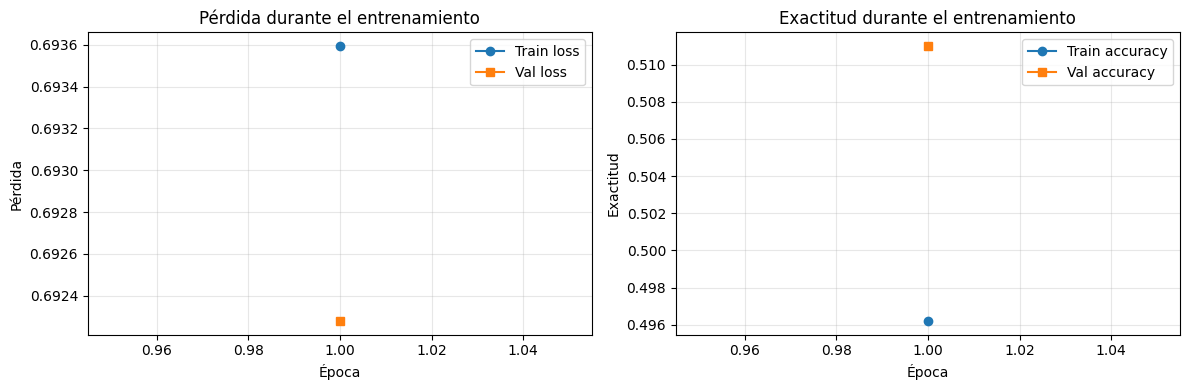

In [9]:
# Gráficas de evolución del entrenamiento
n_epochs = len(hist_lstm["val_loss"])
if n_epochs == 0:
    print("No hay datos para graficar. Ejecuta primero el entrenamiento.")
else:
    epochs = list(range(1, n_epochs + 1))
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist_lstm["train_loss"], marker='o', label="Train loss")
    plt.plot(epochs, hist_lstm["val_loss"], marker='s', label="Val loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title("Pérdida durante el entrenamiento")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_lstm["train_acc"], marker='o', label="Train accuracy")
    plt.plot(epochs, hist_lstm["val_acc"], marker='s', label="Val accuracy")
    plt.xlabel("Época")
    plt.ylabel("Exactitud")
    plt.title("Exactitud durante el entrenamiento")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [10]:
# Ejemplo de inferencia
def predict_sentiment(model, sentence, word2idx):
    model.eval()
    tokens = simple_tokenizer(sentence)
    ids = [word2idx.get(tok,1) for tok in tokens]  # 1 es el índice de UNK
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, time)
    with torch.no_grad():
        logits = model(x)
        pred = logits.argmax(dim=-1).item()
    return "positvo" if pred == 1 else "negativo"

print("Prueba de sentimiento con LSTM manual:")
print(predict_sentiment(lstm_model, "This movie is great!", word2idx))
print(predict_sentiment(lstm_model, "I hated this film.", word2idx))

Prueba de sentimiento con LSTM manual:
negativo
positvo


## Explicación de la implementación LSTM manual

- **`LSTMCell`** define las ecuaciones clásicas de una LSTM con compuertas de entrada, olvido, salida y candidato.
  - La matriz `W` proyecta la concatenación de la entrada `x` y el estado oculto anterior `h_prev` a un vector de tamaño `4 * hidden_dim`, del cual extraemos `i, f, g, o`.
  - Calculamos el nuevo estado de celda `c = f * c_prev + i * g` y la salida `h = o * tanh(c)`.
- **`LSTMClassifier`** itera sobre cada paso temporal, llamando a `LSTMCell` secuencialmente. El grafo computacional se construye dinámicamente; al llamar a `.backward()` en la pérdida final, PyTorch aplica automáticamente **Backpropagation Through Time (BPTT)**.
- El entrenamiento usa entropía cruzada, optimizador Adam y evaluación sobre el conjunto de prueba.

## Personalización
- Puedes modificar `emb_dim`, `hidden_dim`, número de épocas o tamaño del dataset.
- Para comparar con Elman/Jordan, entrena los modelos previos con los mismos parámetros y grafica en la misma figura.